In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li{font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
</style>
"""))

**<font size="10" color="red">ch7.라이브러리를 이용한 시계열 데이터 분석 </font>**

- statsmodels : 통계분석을 하기 위한 라이브러리 (회귀분석, 시계열분석, 가설검정,기술통계)
    * 주기적인 데이터의 트렌드 추이
    
- Prophet : 계정설 추세, 휴일효과 자동으로 모델링

- nunique() : Pandas에서 중복을 제외한 고유한 값(unique value)의 개수를 구하는 함수
    * nunique = number of unique → "서로 다른 값이 몇 종류인가?"**라고 기억하면 됨.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
# 한글설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈 한글 깨짐 해결
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 해결

In [5]:
# data.go.kr / 에어코리아(AirKorea) 다운로드
df = pd.read_csv('data/일별평균대기오염도_2022(에어코리아).csv', encoding='cp949')
df.tail()

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
18245,20221231,구로구,0.037,0.009,0.5,0.004,43.0,29.0
18246,20221231,광진구,0.026,0.005,0.8,0.003,44.0,34.0
18247,20221231,관악산,0.008,0.038,0.3,0.005,29.0,18.0
18248,20221231,관악구,0.045,0.009,0.7,0.003,42.0,28.0
18249,20221231,공항대로,0.042,0.007,0.7,0.004,41.0,31.0


**<font size="8" color="red">용어해설</font>**

- tail : 프로그래밍이나 데이터 분석에서는 보통 데이터의 마지막 부분을 확인하는 기능으로 많이 사용 
- statsmodels : 통계 분석과 통계 모델링을 할 때 사용하는 라이브러리
    * 회귀분석, 시계열 분석, 통계 검정 등을 공부할 때 많이 사용
    * 회귀분석 → 회귀계수 → R² → p-value 순서
-     

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   측정일시          18250 non-null  int64  
 1   측정소명          18250 non-null  object 
 2   이산화질소농도(ppm)  18172 non-null  float64
 3   오존농도(ppm)     18176 non-null  float64
 4   일산화탄소농도(ppm)  18174 non-null  float64
 5   아황산가스농도(ppm)  18176 non-null  float64
 6   미세먼지농도(㎍/㎥)   18115 non-null  float64
 7   초미세먼지농도(㎍/㎥)  18122 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 1.1+ MB


In [9]:
# 결측치 있는 데이터
df[df['일산화탄소농도(ppm)'].isna()]
df[df.isna().any(axis=1)] # 결측치가 한열이라도 있는경우
df.loc[df.isna().any(axis=1),'측정소명'].value_counts() # 결측치가 한열이라도 있는 측정소명

남산        43
동대문구      24
관악산       13
한강대로      12
시흥대로      11
북한산       11
항동         9
행주         5
마포아트센터     4
강변북로       4
서초구        3
성북구        2
송파구        2
동작대로       2
세곡         2
도산대로       2
서대문구       2
관악구        2
올림픽공원      1
은평구        1
동작구        1
Name: 측정소명, dtype: int64

In [12]:
# 서울시 측정소명들
print('측정소들:',df['측정소명'].unique())
print('측정소 갯수:',df['측정소명'].nunique())

측정소들: ['강남구' '홍릉로' '행주' '항동' '한강대로' '청계천로' '천호대로' '중랑구' '중구' '종로구' '종로' '정릉로'
 '자연사박물관' '은평구' '용산구' '올림픽공원' '영등포로' '영등포구' '양천구' '신촌로' '시흥대로' '송파구' '세곡'
 '성북구' '성동구' '화랑로' '서초구' '서울숲' '서대문구' '북한산' '마포아트센터' '마포구' '동작대로' '동작구'
 '동대문구' '도산대로' '도봉구' '노원구' '남산' '금천구' '구로구' '광진구' '관악산' '관악구' '공항대로' '강서구'
 '강북구' '강변북로' '강동구' '강남대로']
측정소 갯수: 50


In [13]:
# int형인 측정일시 컬럼을 str로
# pd.to_datetime(df['측정일시'])
# df['측정일시'].astype('adtetime64[ns]')
df['측정일시'] = df['측정일시'].astype(str)
df['측정일시'] = pd.to_datetime(df['측정일시'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   측정일시          18250 non-null  datetime64[ns]
 1   측정소명          18250 non-null  object        
 2   이산화질소농도(ppm)  18172 non-null  float64       
 3   오존농도(ppm)     18176 non-null  float64       
 4   일산화탄소농도(ppm)  18174 non-null  float64       
 5   아황산가스농도(ppm)  18176 non-null  float64       
 6   미세먼지농도(㎍/㎥)   18115 non-null  float64       
 7   초미세먼지농도(㎍/㎥)  18122 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 1.1+ MB


In [16]:
# 50개 측정소명을 매일 기록(그 중 결측치가 있을수있음)
df['측정소명'].value_counts().sort_index().index 

Index(['강남구', '강남대로', '강동구', '강변북로', '강북구', '강서구', '공항대로', '관악구', '관악산', '광진구',
       '구로구', '금천구', '남산', '노원구', '도봉구', '도산대로', '동대문구', '동작구', '동작대로', '마포구',
       '마포아트센터', '북한산', '서대문구', '서울숲', '서초구', '성동구', '성북구', '세곡', '송파구',
       '시흥대로', '신촌로', '양천구', '영등포구', '영등포로', '올림픽공원', '용산구', '은평구', '자연사박물관',
       '정릉로', '종로', '종로구', '중구', '중랑구', '천호대로', '청계천로', '한강대로', '항동', '행주',
       '홍릉로', '화랑로'],
      dtype='object')

In [33]:
# 미세먼지와 초미세 먼지 컬럼에 결측치가 없는 측정소명
df[df['측정소명']=='공항대로'].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 365 entries, 44 to 18249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   측정일시          365 non-null    datetime64[ns]
 1   측정소명          365 non-null    object        
 2   이산화질소농도(ppm)  365 non-null    float64       
 3   오존농도(ppm)     365 non-null    float64       
 4   일산화탄소농도(ppm)  365 non-null    float64       
 5   아황산가스농도(ppm)  365 non-null    float64       
 6   미세먼지농도(㎍/㎥)   365 non-null    float64       
 7   초미세먼지농도(㎍/㎥)  365 non-null    float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 25.7+ KB


In [34]:
loc_name = '공항대로'
df_flt = df[df['측정소명']==loc_name]
df_flt.head()

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
44,2022-01-01,공항대로,0.035,0.010,0.6,0.002,31.0,15.0
93,2022-01-02,공항대로,0.027,0.017,0.5,0.003,37.0,22.0
143,2022-01-03,공항대로,0.041,0.007,0.6,0.003,31.0,18.0
196,2022-01-04,공항대로,0.032,0.010,0.5,0.003,48.0,21.0
244,2022-01-05,공항대로,0.045,0.004,0.8,0.003,56.0,34.0


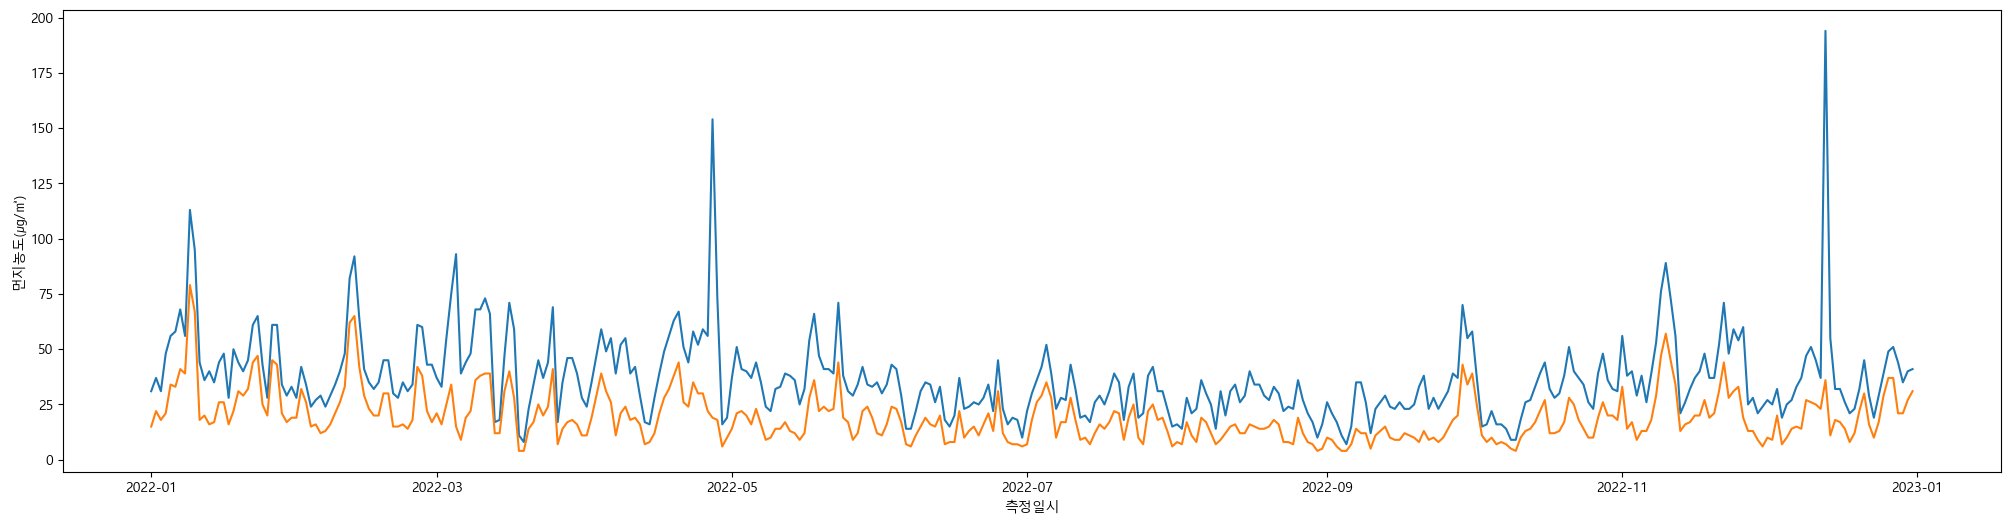

In [35]:
plt.figure(figsize=(25,6))
plt.plot(df_flt['측정일시'],df_flt['미세먼지농도(㎍/㎥)'],label='미세먼지농도')
plt.plot(df_flt['측정일시'],df_flt['초미세먼지농도(㎍/㎥)'],label='초미세먼지농도')
plt.xlabel('측정일시')
plt.ylabel('먼지농도(㎍/㎥)')
plt.show()

# statsmodels를 통한 추이 탐색
- 주기적인 데이터의 트렌드 추이
- 날짜형 인덱스와 데이터 컬럼

In [37]:
df_flt2 = df_flt[['측정일시','미세먼지농도(㎍/㎥)']]
ts=df_flt2.set_index('측정일시')
ts.head()

,미세먼지농도(㎍/㎥)
측정일시,
2022-01-01,31.0
2022-01-02,37.0
2022-01-03,31.0
2022-01-04,48.0
2022-01-05,56.0


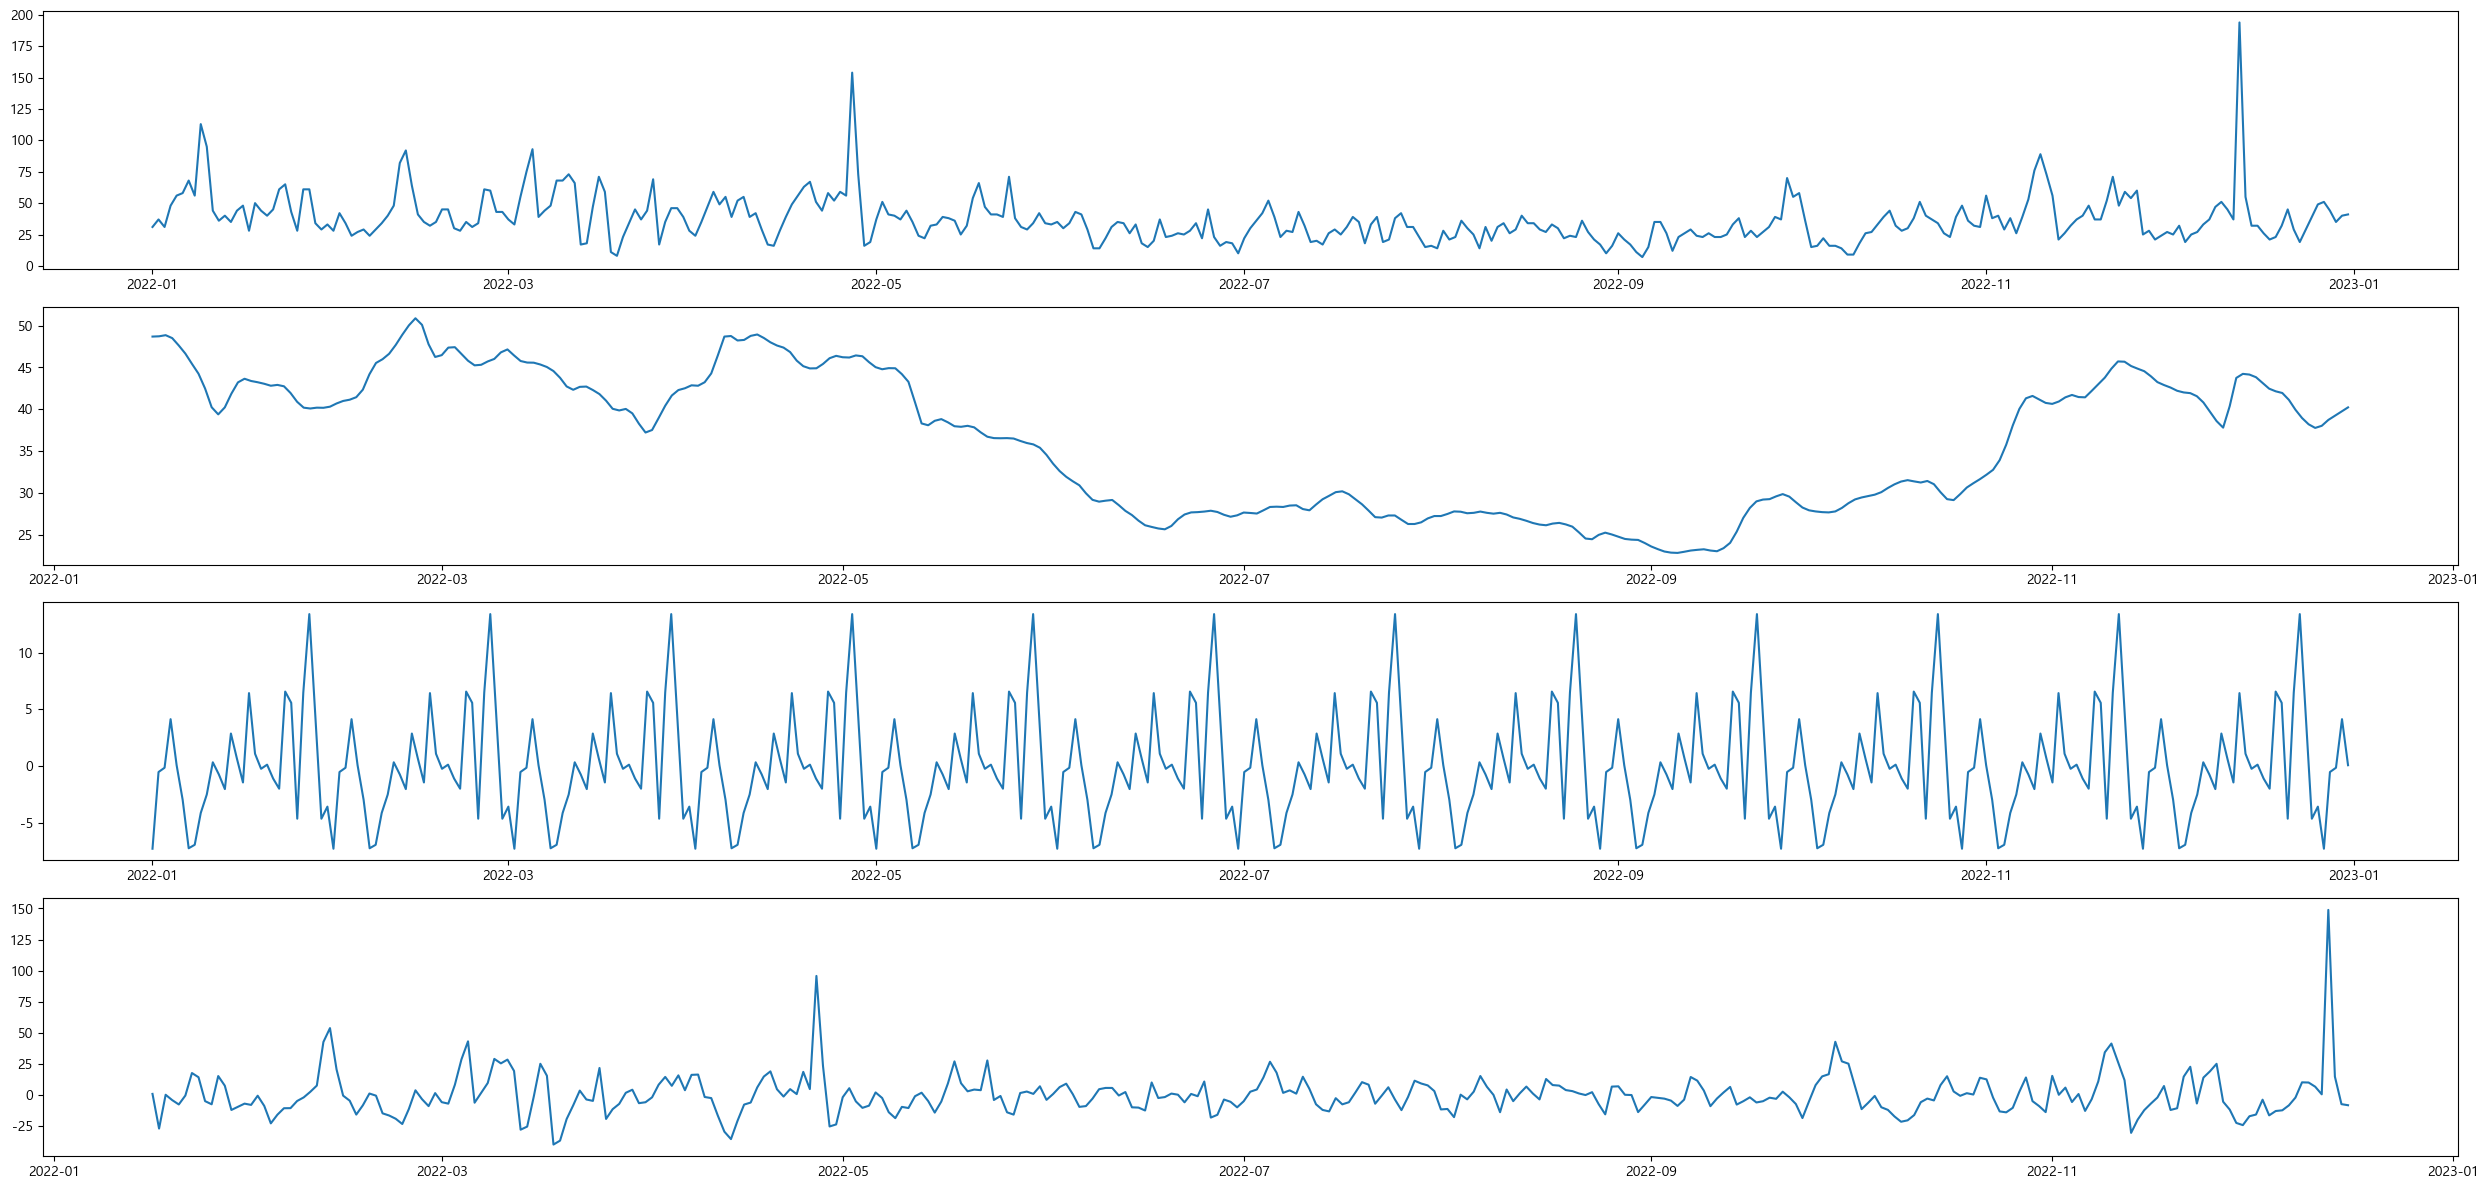

In [42]:
# 시계열 데이터의 구조를 분해해 주는 도구(statsmodels.tsa 시계열 분석 lib패키지)
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(ts['미세먼지농도(㎍/㎥)'],
                           period=30, # 30일 단위로 계절성을 분해해서 해석
                           model ='additive') # '실제값=추세+계절성+잔차'식으로 분석
# result.observed : 실제데이터
# result.seasonal 데이터의 장기적인 변화. 전반적으로 감소, 증가
# result.seasonal # 주기적인 계절성 패턴
# result.resid
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(25,12))
# result.observed.plot(ax=axes[0])
# result.trend.plot(ax=axes[1])
# result.seasonal.plot(ax=axes[2])
# result.resid.plot(ax=axes[3])
axes[0].plot(result.observed)
axes[1].plot(result.trend)
axes[2].plot(result.seasonal)
axes[3].plot(result.resid)
plt.tight_layout()
plt.show()

```
    seasonal_decompose & RNN/LSTM/Seq2Seq & Prophet
        통계적 추이 분석       예측            추이&예측
```
# Prophet 

- 계절성, 추이, 휴일효과 등을 자동으로 모델링(facebook에서 개발한 시계열예측 라이브러리)
- pip install prophet

In [43]:
df_flt2.sample()

,측정일시,미세먼지농도(㎍/㎥)
10746,2022-08-03,28.0


In [44]:
df_flt2.columns = ['ds','y']
df_flt2.sample()

,ds,y
543,2022-01-11,44.0


In [45]:
from prophet import Prophet
# 1. 모델생성
p_model = Prophet()
# 2. 모델학습
p_model.fit(df_flt2)

Importing plotly failed. Interactive plots will not work.
14:50:43 - cmdstanpy - INFO - Chain [1] start processing
14:50:43 - cmdstanpy - INFO - Chain [1] done processing


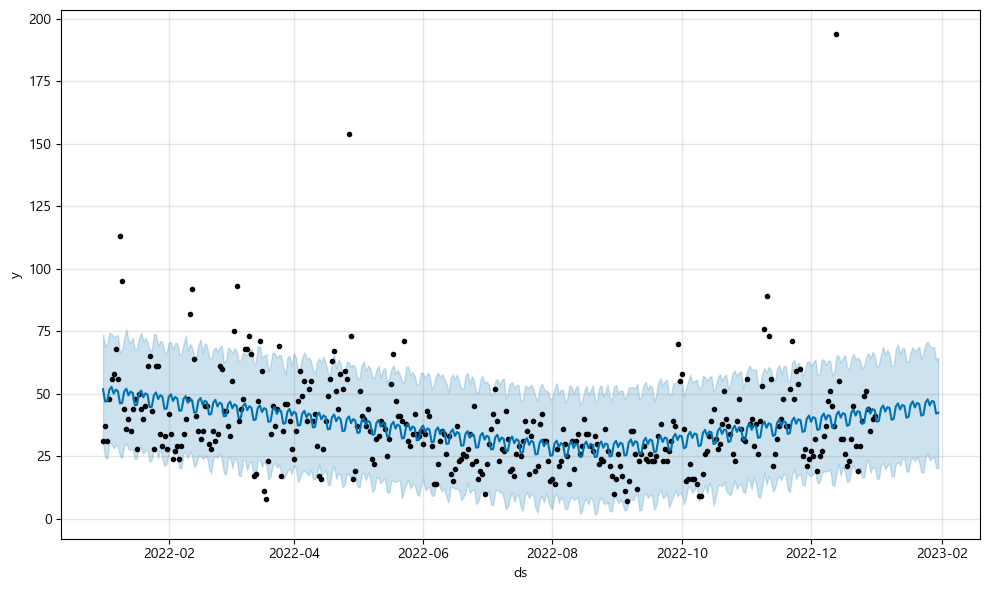

In [46]:
# p_model을 이용하여 30일 이후의 데이터를 예측하고 추이
# 3. 미래 데이터 프래임을 생성(30일)
future = p_model.make_future_dataframe(periods=30)
# 4. 예측수행
forecast = p_model.predict(future)
# 5. 시각화
p = p_model.plot(forecast)

In [48]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(30)
# forecast : yhat을 추세+계절성+기타요인

,ds,yhat,yhat_lower,yhat_upper
365,2023-01-01,38.760344,16.233085,60.469467
366,2023-01-02,39.131423,15.710062,61.550869
367,2023-01-03,44.001296,21.501887,65.680025
368,2023-01-04,45.309448,22.254647,68.813754
369,2023-01-05,42.843737,19.875091,65.392022
370,2023-01-06,44.648279,21.218514,67.650357
371,2023-01-07,44.295943,22.222474,65.689290
372,2023-01-08,39.573621,16.975306,61.120828
373,2023-01-09,39.944700,16.792551,61.180637
374,2023-01-10,44.814573,21.815188,67.985583


In [49]:
forecast.loc[forecast['ds']=='2023-01-15',['yhat','yhat_lower','yhat_upper']]

,yhat,yhat_lower,yhat_upper
379,40.386897,18.635573,62.99281
